# 15 - Anomaly Results Analysis

This notebook summarises anomaly detection results produced by AquaPulse and investigates potentially concerning dissolved oxygen conditions.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "anomaly_detection_results.csv"
)

if FILE.exists():

    anomalies = pd.read_csv(
        FILE,
        low_memory=False
    )

    print(anomalies.shape)
    display(anomalies.head())

else:
    print("Anomaly results file is not currently available.")

(308, 12)


,timestamp,sensor_id,sensor_name,dissolved_oxygen_mgl,dissolved_oxygen_pct,pollution_alert,anomaly_type,anomaly_label,temperature,air_temperature_c,sunshine_wm2,cloud_cover_pct
0,2025-06-18 08:18:21,941115,Derwent 13-50,6.9,65.2,0,2,Possible battery or communication gap,13.0,16.0,304.0,100.0
1,2025-06-18 16:34:11,941115,Derwent 13-50,6.3,63.6,0,2,Possible battery or communication gap,15.8,21.3,636.0,85.0
2,2025-06-18 20:58:13,941115,Derwent 13-50,6.1,60.4,0,2,Possible battery or communication gap,14.9,17.5,78.0,0.0
3,2025-06-25 17:17:56,941115,Derwent 13-50,10.2,100.2,0,2,Possible battery or communication gap,14.9,20.7,331.0,100.0
4,2025-08-25 15:50:19,941115,Derwent 13-50,10.0,101.8,0,2,Possible battery or communication gap,16.3,24.7,586.0,26.0


anomaly_type
1    231
2     77
Name: count, dtype: int64


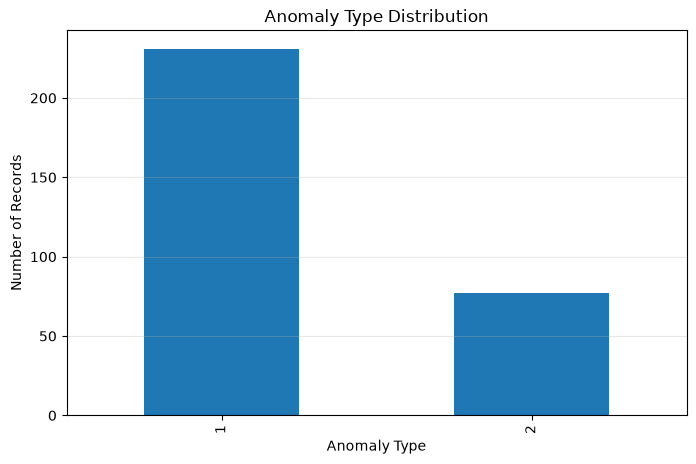

In [2]:
if FILE.exists() and "anomaly_type" in anomalies.columns:

    counts = (
        anomalies["anomaly_type"]
        .value_counts()
        .sort_index()
    )

    print(counts)

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")

    plt.title("Anomaly Type Distribution")
    plt.xlabel("Anomaly Type")
    plt.ylabel("Number of Records")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [3]:
if FILE.exists() and "dissolved_oxygen_mgl" in anomalies.columns:

    low_do = anomalies[
        pd.to_numeric(
            anomalies["dissolved_oxygen_mgl"],
            errors="coerce"
        ) < 4
    ]

    print("DO readings below 4 mg/L:", len(low_do))

    display(low_do.head(20))

DO readings below 4 mg/L: 231


,timestamp,sensor_id,sensor_name,dissolved_oxygen_mgl,dissolved_oxygen_pct,pollution_alert,anomaly_type,anomaly_label,temperature,air_temperature_c,sunshine_wm2,cloud_cover_pct
33,2025-06-20 01:42:31,sensor022,Derwent 13,3.0,28.5,1,1,Possible biofouling / isolated low DO,13.9,14.1,0.0,100.0
34,2025-06-20 01:54:28,sensor022,Derwent 13,3.7,35.9,1,1,Possible biofouling / isolated low DO,13.8,14.1,0.0,100.0
79,2026-05-30 01:35:15,sensor022,Derwent 13,3.5,32.8,1,1,Possible biofouling / isolated low DO,13.3,9.6,0.0,57.0
80,2026-05-30 01:47:14,sensor022,Derwent 13,3.4,32.4,1,1,Possible biofouling / isolated low DO,13.2,9.6,0.0,57.0
81,2026-05-30 15:46:21,sensor022,Derwent 13,3.6,35.4,1,1,Possible biofouling / isolated low DO,14.7,20.9,744.0,57.0
82,2026-05-30 16:34:16,sensor022,Derwent 13,3.5,34.7,1,1,Possible biofouling / isolated low DO,14.7,20.7,616.0,95.0
83,2026-05-30 16:46:15,sensor022,Derwent 13,3.1,30.0,1,1,Possible biofouling / isolated low DO,14.7,20.7,616.0,95.0
84,2026-05-30 18:34:10,sensor022,Derwent 13,3.8,37.4,1,1,Possible biofouling / isolated low DO,14.5,19.4,264.0,100.0
85,2026-05-30 18:46:09,sensor022,Derwent 13,3.5,34.2,1,1,Possible biofouling / isolated low DO,14.5,19.4,264.0,100.0
86,2026-05-30 19:22:06,sensor022,Derwent 13,3.6,35.4,1,1,Possible biofouling / isolated low DO,14.4,18.3,134.0,99.0


## Interpretation

Anomaly detection complements DO forecasting by highlighting river conditions that may require attention. Low dissolved oxygen is particularly important because substantial reductions can negatively affect aquatic ecosystems.

AquaPulse presents anomaly information in a more understandable form through Green, Orange and Red condition levels.